In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scanpy import read_h5ad
from scanpy.pp import regress_out

In [ ]:
#gtex = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_scaled.h5ad') # no  ct fractions for gtex

adata = '/projects/bioinformatics/DB/Xena/TCGA_GTEX/by_tissue_primary_vs_normal/pancreas/tumor/pancreatic_adenocarcinoma/pancreatic_adenocarcinoma.h5ad'
adata = read_h5ad(adata)

ct_cols = [
    'Lymphocytes',
    'Neutrophils',
    'Eosinophils',
    'Mast_Cells',
    'Dendritic_Cells',
    'Macrophages',
    'tumor_purity',
]

celltypes = pd.read_csv('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes/tcga_celltypes.csv', index_col=0)
obs_names = tcga.obs_names

common = obs_names.intersection(celltypes.index)

tcga.obs = tcga.obs.join(
    celltypes.dropna().reindex(tcga.obs_names)
)

# keep only samples where ALL covariates exist
mask = tcga.obs[ct_cols].notna().all(axis=1)

tcga = tcga[mask].copy()

In [ ]:
import numpy as np
import scanpy as sc

# store original
tcga.layers['orig'] = tcga.X.copy()

# init regressed matrix
X_regressed = np.zeros_like(tcga.X)

# loop over conditions
for cond in tcga.obs['condition'].unique():
    idx = tcga.obs['condition'] == cond
    adata_sub = tcga[idx].copy()
    
    # regress out within this condition
    sc.pp.regress_out(adata_sub, ct_cols)
    
    # write back to correct rows
    X_regressed[idx, :] = adata_sub.X

# store result
tcga.layers['regressed'] = X_regressed

In [ ]:
import numpy as np
from scipy.stats import pearsonr

X_orig = tcga.layers['orig']
X_reg  = tcga.layers['regressed']

r_vals = []

for g in range(X_orig.shape[1]):
    x = X_orig[:, g]
    y = X_reg[:, g]

    # skip constant genes
    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        continue

    r = np.corrcoef(x, y)[0, 1]
    r_vals.append(r)

r_vals = np.array(r_vals)

print("Mean R2 between regressed and orig:", np.mean(r_vals**2))
print("Mean variance explained by covs:", 1 - np.mean(r_vals**2))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
from ast import literal_eval
import time
import os


def run_interaction_analysis(
    adata,
    covs,
    interaction_file,
    dataset_prefix=None,
    save_corr=False,
    load_corr=False,
    save_plot=False,
):

    t0_total = time.time()
    print("\n=== STARTING ANALYSIS ===")

    save_dir = "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes"
    dataset_name = dataset_prefix if dataset_prefix else "dataset"

    # -----------------------------
    # Load interactions
    # -----------------------------
    print("\n[1/6] Loading interactions...")

    interactions = pd.read_csv(interaction_file)
    interactions["all_genes"] = interactions["all_genes"].apply(literal_eval)
    genes = interactions["all_genes"].explode().unique()

    print(f"Interactions: {len(interactions)} | Genes: {len(genes)}")

    # -----------------------------
    # Subset AnnData
    # -----------------------------
    print("\n[2/6] Subsetting genes...")

    adata_sub = adata[:, adata.var_names.isin(genes)].copy()

    # -----------------------------
    # Load matrices from layers
    # -----------------------------
    print("\n[3/6] Loading layers...")

    X_orig = adata_sub.layers["orig"].copy()
    X_reg = adata_sub.layers["regressed"].copy()

    if hasattr(X_orig, "toarray"):
        X_orig = X_orig.toarray()
    if hasattr(X_reg, "toarray"):
        X_reg = X_reg.toarray()

    X_orig = X_orig.astype(np.float32)
    X_reg = X_reg.astype(np.float32)

    gene_names = adata_sub.var_names

    # -----------------------------
    # correlation matrices
    # -----------------------------
    print("\n[4/6] Computing correlations...")

    def corr(X):
        X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
        return (X.T @ X) / (X.shape[0] - 1)

    corr_mat = pd.DataFrame(
        corr(X_orig),
        index=gene_names,
        columns=gene_names
    )

    pcorr_mat = pd.DataFrame(
        corr(X_reg),
        index=gene_names,
        columns=gene_names
    )

    matrices = {
        "corr": corr_mat,
        "pcorr": pcorr_mat
    }

    # -----------------------------
    # interaction pairs
    # -----------------------------
    print("\n[5/6] Preparing interactions...")

    interactions["g1"] = interactions["all_genes"].apply(lambda x: x[0])
    interactions["g2"] = interactions["all_genes"].apply(lambda x: x[1])

    int_pairs = {
        tuple(sorted((a, b)))
        for a, b in zip(interactions.g1, interactions.g2)
    }

    # -----------------------------
    # AUROC
    # -----------------------------
    print("\n[6/6] AUROC...")

    results = []
    plt.figure(figsize=(7, 6))

    for name in ["corr", "pcorr"]:
        print(f"\nProcessing {name}")

        mat = matrices[name]

        mask = np.tril(np.ones(mat.shape), k=-1).astype(bool)
        values = mat.values[mask]

        idx = np.array(np.where(mask)).T
        genes_list = list(mat.index)

        labels = np.array([
            1 if tuple(sorted((genes_list[i], genes_list[j]))) in int_pairs else 0
            for i, j in idx
        ])

        if len(np.unique(labels)) < 2:
            auroc = np.nan
            fpr, tpr = [0, 1], [0, 1]
        else:
            auroc = roc_auc_score(labels, values)
            fpr, tpr, _ = roc_curve(labels, values)

        print(f"AUROC {name}: {auroc:.4f}")

        pos = values[labels == 1]
        neg = values[labels == 0]

        if len(pos) > 0 and len(neg) > 0:
            U, p = mannwhitneyu(pos, neg, alternative="greater")
        else:
            U, p = np.nan, np.nan

        results.append({
            "type": name,
            "auroc": auroc,
            "U": U,
            "p": p,
            "interaction_file": dataset_name
        })

        plt.plot(fpr, tpr, label=f"{name} AUC={auroc:.2f}")

    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.legend()
    plt.title(dataset_name)
    plt.tight_layout()

    if save_plot:
        out = os.path.join(save_dir, f"{dataset_name}_roc.png")
        plt.savefig(out, dpi=150)

    plt.show()

    print(f"\nTOTAL TIME: {time.time() - t0_total:.2f}s")

    return matrices, pd.DataFrame(results)

# Regress Out Cell Types

In [ ]:
#gtex = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_scaled.h5ad') # no  ct fractions for gtex
tcga = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_scaled.h5ad')

ct_cols = [
    'Lymphocytes',
    'Neutrophils',
    'Eosinophils',
    'Mast_Cells',
    'Dendritic_Cells',
    'Macrophages',
    'tumor_purity',
]

celltypes = pd.read_csv('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes/tcga_celltypes.csv', index_col=0)
obs_names = tcga.obs_names

common = obs_names.intersection(celltypes.index)

tcga.obs = tcga.obs.join(
    celltypes.dropna().reindex(tcga.obs_names)
)

# keep only samples where ALL covariates exist
mask = tcga.obs[ct_cols].notna().all(axis=1)

tcga = tcga[mask].copy()

In [ ]:
import numpy as np
import scanpy as sc

# store original
tcga.layers['orig'] = tcga.X.copy()

# init regressed matrix
X_regressed = np.zeros_like(tcga.X)

# loop over conditions
for cond in tcga.obs['condition'].unique():
    idx = tcga.obs['condition'] == cond
    adata_sub = tcga[idx].copy()
    
    # regress out within this condition
    sc.pp.regress_out(adata_sub, ct_cols)
    
    # write back to correct rows
    X_regressed[idx, :] = adata_sub.X

# store result
tcga.layers['regressed'] = X_regressed

In [ ]:
import numpy as np
from scipy.stats import pearsonr

X_orig = tcga.layers['orig']
X_reg  = tcga.layers['regressed']

r_vals = []

for g in range(X_orig.shape[1]):
    x = X_orig[:, g]
    y = X_reg[:, g]

    # skip constant genes
    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        continue

    r = np.corrcoef(x, y)[0, 1]
    r_vals.append(r)

r_vals = np.array(r_vals)

print("Mean R2 between regressed and orig:", np.mean(r_vals**2))
print("Mean variance explained by covs:", 1 - np.mean(r_vals**2))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
from ast import literal_eval
import time
import os


def run_interaction_analysis(
    adata,
    covs,
    interaction_file,
    dataset_prefix=None,
    save_corr=False,
    load_corr=False,
    save_plot=False,
):

    t0_total = time.time()
    print("\n=== STARTING ANALYSIS ===")

    save_dir = "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes"
    dataset_name = dataset_prefix if dataset_prefix else "dataset"

    # -----------------------------
    # Load interactions
    # -----------------------------
    print("\n[1/6] Loading interactions...")

    interactions = pd.read_csv(interaction_file)
    interactions["all_genes"] = interactions["all_genes"].apply(literal_eval)
    genes = interactions["all_genes"].explode().unique()

    print(f"Interactions: {len(interactions)} | Genes: {len(genes)}")

    # -----------------------------
    # Subset AnnData
    # -----------------------------
    print("\n[2/6] Subsetting genes...")

    adata_sub = adata[:, adata.var_names.isin(genes)].copy()

    # -----------------------------
    # Load matrices from layers
    # -----------------------------
    print("\n[3/6] Loading layers...")

    X_orig = adata_sub.layers["orig"].copy()
    X_reg = adata_sub.layers["regressed"].copy()

    if hasattr(X_orig, "toarray"):
        X_orig = X_orig.toarray()
    if hasattr(X_reg, "toarray"):
        X_reg = X_reg.toarray()

    X_orig = X_orig.astype(np.float32)
    X_reg = X_reg.astype(np.float32)

    gene_names = adata_sub.var_names

    # -----------------------------
    # correlation matrices
    # -----------------------------
    print("\n[4/6] Computing correlations...")

    def corr(X):
        X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
        return (X.T @ X) / (X.shape[0] - 1)

    corr_mat = pd.DataFrame(
        corr(X_orig),
        index=gene_names,
        columns=gene_names
    )

    pcorr_mat = pd.DataFrame(
        corr(X_reg),
        index=gene_names,
        columns=gene_names
    )

    matrices = {
        "corr": corr_mat,
        "pcorr": pcorr_mat
    }

    # -----------------------------
    # interaction pairs
    # -----------------------------
    print("\n[5/6] Preparing interactions...")

    interactions["g1"] = interactions["all_genes"].apply(lambda x: x[0])
    interactions["g2"] = interactions["all_genes"].apply(lambda x: x[1])

    int_pairs = {
        tuple(sorted((a, b)))
        for a, b in zip(interactions.g1, interactions.g2)
    }

    # -----------------------------
    # AUROC
    # -----------------------------
    print("\n[6/6] AUROC...")

    results = []
    plt.figure(figsize=(7, 6))

    for name in ["corr", "pcorr"]:
        print(f"\nProcessing {name}")

        mat = matrices[name]

        mask = np.tril(np.ones(mat.shape), k=-1).astype(bool)
        values = mat.values[mask]

        idx = np.array(np.where(mask)).T
        genes_list = list(mat.index)

        labels = np.array([
            1 if tuple(sorted((genes_list[i], genes_list[j]))) in int_pairs else 0
            for i, j in idx
        ])

        if len(np.unique(labels)) < 2:
            auroc = np.nan
            fpr, tpr = [0, 1], [0, 1]
        else:
            auroc = roc_auc_score(labels, values)
            fpr, tpr, _ = roc_curve(labels, values)

        print(f"AUROC {name}: {auroc:.4f}")

        pos = values[labels == 1]
        neg = values[labels == 0]

        if len(pos) > 0 and len(neg) > 0:
            U, p = mannwhitneyu(pos, neg, alternative="greater")
        else:
            U, p = np.nan, np.nan

        results.append({
            "type": name,
            "auroc": auroc,
            "U": U,
            "p": p,
            "interaction_file": dataset_name
        })

        plt.plot(fpr, tpr, label=f"{name} AUC={auroc:.2f}")

    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.legend()
    plt.title(dataset_name)
    plt.tight_layout()

    if save_plot:
        out = os.path.join(save_dir, f"{dataset_name}_roc.png")
        plt.savefig(out, dpi=150)

    plt.show()

    print(f"\nTOTAL TIME: {time.time() - t0_total:.2f}s")

    return matrices, pd.DataFrame(results)

In [ ]:
interaction_files = [
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv",
]

all_results = []

for f in interaction_files:
    prefix = f.split("/")[-1].replace(".csv","")
    matrices, results_df = run_interaction_analysis(
        adata=tcga,
        covs=ct_cols,
        interaction_file=f,
        dataset_prefix=prefix,
        save_corr=True,
        load_corr=False,
        save_plot=False,
    )
    results_df['interaction_file'] = prefix
    all_results.append(results_df)

all_results_df = pd.concat(all_results).reset_index(drop=True)
#all_results_df.to_csv("/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/celltypes/aurocs_ccis_intact.csv")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure correct file order
file_order = [
    "ccc_lr_pairs",
    "intact_direct",
    "intact_physical",
    "intact_association"
]

df = all_results_df.copy()

df['dataset'] = 'tcga'

df["interaction_file"] = pd.Categorical(
    df["interaction_file"],
    categories=file_order,
    ordered=True
)
df = df.sort_values("interaction_file")

## Color scheme
#colors = {"tcga": "#ab3502ff", "gtex": "#00728eff"}
colors = {"corr": "#ab3502ff", "pcorr": "gray"}

# Marker and linestyle mapping
markers = {"tcga": "s", "gtex": "o"}
linestyles = {"corr": "solid", "pcorr": "dashed"}

plt.figure(figsize=(6, 6))

for dataset in df["dataset"].unique():
    for corr_type in ["corr", "pcorr"]:
        subset = df[(df["dataset"] == dataset) & (df["type"] == corr_type)]
        
        dataset_label = dataset.replace('tcga', 'TCGA').replace('gtex', 'GTEx')
        corr_label = corr_type.replace('pcorr', 'Partial Correlation').replace('corr', 'Pearson Correlation')
        
        plt.plot(
            subset["interaction_file"],
            subset["auroc"],
            marker=markers[dataset],
            linestyle=linestyles[corr_type],
            color=colors[corr_type],
            linewidth=2,
            markersize=8,
            label=f"{dataset_label}, {corr_label}"
        )

plt.xlabel("")
plt.ylabel("AUROC")
plt.title("Prediction of Interacting Pairs Across Interaction Types")
plt.xticks(
    ticks=range(len(file_order)),
    labels=['CCIs', 'IA Direct', 'IA Physical', 'IA Association'],
    rotation=45
)
plt.legend(handlelength=4)

plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/pcorr_celltypes_aurocs_ccis_intact.png", bbox_inches='tight', dpi=300)
plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/pcorr_celltypes_aurocs_ccis_intact.pdf", bbox_inches='tight', dpi=300)

plt.show()

# Spearman Corr

In [2]:
gtex = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/gtex_scaled.h5ad')
tcga = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_scaled.h5ad')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

def compute_grouped_matrices(X, groups):
    if not isinstance(X, np.ndarray):
        X = X.toarray()
    
    skew_list = []
    kurt_list = []
    
    for g in np.unique(groups):
        mask = groups == g
        X_sub = X[mask]
        
        skew_list.append(skew(X_sub, axis=0))
        kurt_list.append(kurtosis(X_sub, axis=0))
    
    skew_mat = np.vstack(skew_list)
    kurt_mat = np.vstack(kurt_list)
    
    return skew_mat, kurt_mat


# ---------- TCGA ----------
tcga_skew_mat, tcga_kurt_mat = compute_grouped_matrices(
    tcga.X,
    tcga.obs['condition'].values
)

# ---------- GTEx ----------
gtex_skew_mat, gtex_kurt_mat = compute_grouped_matrices(
    gtex.X,
    gtex.obs['condition'].values
)

In [36]:
def median_mad(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    return median, mad


def print_summary(name, x, metric):
    m, mad = median_mad(x)
    print(f"{name} {metric}: {m:.4f} ± {mad:.4f}")

skew_all = np.concatenate([
    tcga_skew_mat.flatten(),
    gtex_skew_mat.flatten()
])

kurt_all = np.concatenate([
    tcga_kurt_mat.flatten(),
    gtex_kurt_mat.flatten()
])
    
# TCGA
print_summary("TCGA", tcga_skew_mat, "skew")
print_summary("TCGA", tcga_kurt_mat, "kurtosis")

# GTEx
print_summary("GTEx", gtex_skew_mat, "skew")
print_summary("GTEx", gtex_kurt_mat, "kurtosis")

# All
print_summary("Skew (TCGA + GTEx)", skew_all, 'skew')
print_summary("Kurtosis (TCGA + GTEx)", kurt_all, 'kurtosis')

TCGA skew: 0.1630 ± 0.3087
TCGA kurtosis: 0.4051 ± 0.5572
GTEx skew: 0.1193 ± 0.3772
GTEx kurtosis: 0.4757 ± 0.6357
Skew (TCGA + GTEx) skew: 0.1404 ± 0.3452
Kurtosis (TCGA + GTEx) kurtosis: 0.4423 ± 0.5990


In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata
from ast import literal_eval
import os
import time
from concurrent.futures import ProcessPoolExecutor, as_completed


def process_dataset(name, adata, interactions):

    t_ds = time.time()

    # Subset adata to genes in the interaction file
    file_genes = set(interactions["g1"]) | set(interactions["g2"])
    keep = [g for g in adata.var_names if g in file_genes]
    adata_sub = adata[:, keep]

    genes = adata_sub.var_names.to_list()
    gene_index = {g: i for i, g in enumerate(genes)}
    n = len(genes)
    print(f"    [{name}] Subset to {n} genes")

    # Build adjacency matrix
    inter_mat = np.zeros((n, n), dtype=np.int8)
    hit = 0
    for a, b in zip(interactions["g1"], interactions["g2"]):
        if a in gene_index and b in gene_index:
            i, j = gene_index[a], gene_index[b]
            inter_mat[i, j] = 1
            inter_mat[j, i] = 1
            hit += 1
    print(f"    [{name}] Mapped edges: {hit}/{len(interactions)}")

    # Expression matrix
    X = adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else np.asarray(adata_sub.X)
    X = X.astype(np.float32)

    # Pearson
    Xp = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    pearson = (Xp.T @ Xp) / (X.shape[0] - 1)

    # Spearman
    Xr = rankdata(X, axis=0).astype(np.float32)
    Xr = (Xr - Xr.mean(axis=0)) / (Xr.std(axis=0) + 1e-8)
    spearman = (Xr.T @ Xr) / (X.shape[0] - 1)

    # --- similarity between Pearson and Spearman matrices ---
    rows, cols = np.triu_indices(n, k=1)

    r = np.corrcoef(pearson[rows, cols], spearman[rows, cols])[0, 1]
    r2 = r ** 2

    # AUROC
    rows, cols = np.tril_indices(n, k=-1)
    labels    = inter_mat[rows, cols]
    pearson_auc  = roc_auc_score(labels, pearson[rows, cols])  if labels.max() > 0 else np.nan
    spearman_auc = roc_auc_score(labels, spearman[rows, cols]) if labels.max() > 0 else np.nan

    print(
        f"    [{name}] Pearson AUC: {pearson_auc:.4f}  "
        f"Spearman AUC: {spearman_auc:.4f}  "
        f"Pearson~Spearman R: {r:.4f}  R²: {r2:.4f}  "
        f"({time.time()-t_ds:.1f}s)"
    )
    return {"dataset": name, "pearson_auroc": pearson_auc, "spearman_auroc": spearman_auc}


def run_interaction_analysis(adatas, interaction_file, dataset_prefix=None, save_corr=False):

    t0 = time.time()
    save_dir = "/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/spearman"
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n=== START: {interaction_file} ===")

    interactions = pd.read_csv(interaction_file)
    interactions["all_genes"] = interactions["all_genes"].apply(literal_eval)
    interactions["g1"] = interactions["all_genes"].str[0]
    interactions["g2"] = interactions["all_genes"].str[1]
    print(f"    Loaded {len(interactions)} interactions")

    with ProcessPoolExecutor() as pool:
        futures = {pool.submit(process_dataset, name, adata, interactions): name for name, adata in adatas.items()}
        results = [fut.result() for fut in as_completed(futures)]

    out = pd.DataFrame(results)
    out_file = f"{save_dir}/{dataset_prefix}_auroc_results.csv"
    out.to_csv(out_file, index=False)
    print(f"\n=== DONE — {time.time()-t0:.1f}s === Saved: {out_file}")
    return out

In [48]:
adatas = {"gtex": gtex, "tcga": tcga}
interaction_files = [
    "/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv",
    "/home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv",
]

all_results = []

for f in interaction_files:
    prefix = f.split("/")[-1].replace(".csv","")
    results_df = run_interaction_analysis(
        adatas,
        interaction_file=f,
        dataset_prefix=prefix,
        save_corr=True,
    )
    results_df['interaction_file'] = prefix
    all_results.append(results_df)

all_results_df = pd.concat(all_results).reset_index(drop=True)
all_results_df.to_csv("/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/spearman/aurocs_ccis_intact.csv")


=== START: /home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv ===
    Loaded 3748 interactions
    [gtex] Subset to 369 genes
    [gtex] Mapped edges: 319/3748
    [gtex] Pearson AUC: 0.6311  Spearman AUC: 0.6244  Pearson~Spearman R: 0.9945  R²: 0.9890  (0.4s)
    [tcga] Subset to 531 genes
    [tcga] Mapped edges: 600/3748
    [tcga] Pearson AUC: 0.6770  Spearman AUC: 0.6754  Pearson~Spearman R: 0.9982  R²: 0.9964  (0.8s)

=== DONE — 5.2s === Saved: /projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/spearman/ccc_lr_pairs_auroc_results.csv

=== START: /home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv ===
    Loaded 7852 interactions
    [gtex] Subset to 3027 genes
    [gtex] Mapped edges: 4577/7852
    [tcga] Subset to 3354 genes
    [tcga] Mapped edges: 5484/7852
    [gtex] Pearson AUC: 0.5800  Spearman AUC: 0.5788  Pearson~Spearman R: 0.9948  R²: 0.9896  (6.7s)
    [tcga] Pearson AUC: 0.5854  Spearman AUC: 0.5868  Pearson~Spearman R:

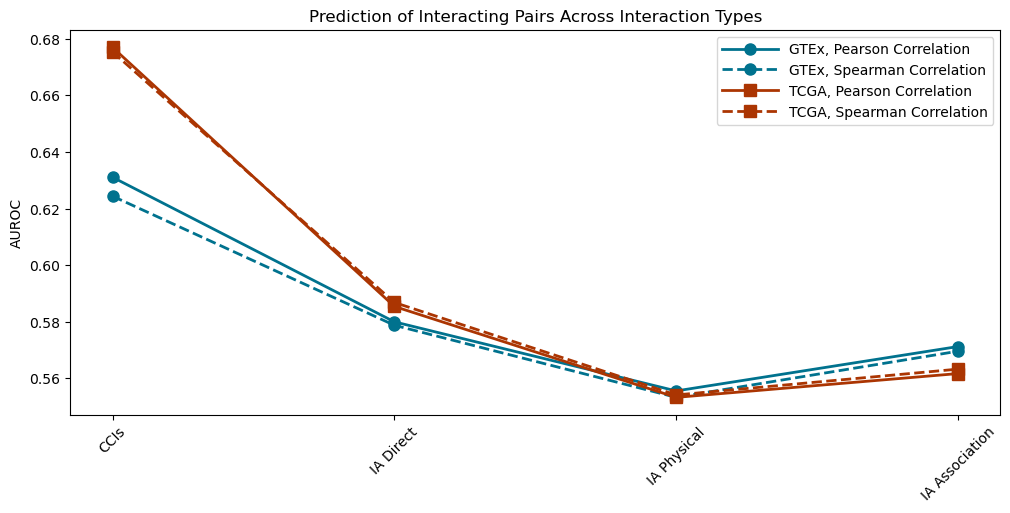

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

all_results_df = pd.read_csv("/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/spearman/aurocs_ccis_intact.csv")

# Ensure correct file order
file_order = [
    "ccc_lr_pairs",
    "intact_direct",
    "intact_physical",
    "intact_association"
]

all_results_df = all_results_df.melt(
    id_vars=["dataset", "interaction_file"],
    value_vars=["pearson_auroc", "spearman_auroc"],
    var_name="type",
    value_name="auroc"
)
all_results_df["type"] = all_results_df["type"].str.replace("_auroc", "")

df = all_results_df.copy()

df["interaction_file"] = pd.Categorical(
    df["interaction_file"],
    categories=file_order,
    ordered=True
)
df = df.sort_values("interaction_file")

# Color scheme
colors = {"tcga": "#ab3502ff", "gtex": "#00728eff"}

# Marker and linestyle mapping
markers = {"tcga": "s", "gtex": "o"}
linestyles = {"pearson": "solid", "spearman": "dashed"}

plt.figure(figsize=(12, 5))

for dataset in df["dataset"].unique():
    for corr_type in ["pearson", "spearman"]:
        subset = df[(df["dataset"] == dataset) & (df["type"] == corr_type)]
        
        dataset_label = dataset.replace('tcga', 'TCGA').replace('gtex', 'GTEx')
        corr_label = corr_type.replace('spearman', 'Spearman Correlation').replace('pearson', 'Pearson Correlation')
        
        plt.plot(
            subset["interaction_file"],
            subset["auroc"],
            marker=markers[dataset],
            linestyle=linestyles[corr_type],
            color=colors[dataset],
            linewidth=2,
            markersize=8,
            label=f"{dataset_label}, {corr_label}"
        )

plt.xlabel("")
plt.ylabel("AUROC")
plt.title("Prediction of Interacting Pairs Across Interaction Types")
plt.xticks(
    ticks=range(len(file_order)),
    labels=['CCIs', 'IA Direct', 'IA Physical', 'IA Association'],
    rotation=45
)
plt.legend(handlelength=4)

plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/spearman_vs_pearson_aurocs_ccis_intact.png", bbox_inches='tight', dpi=300)
plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/images/spearman_vs_pearson_aurocs_ccis_intact.pdf", bbox_inches='tight', dpi=300)

plt.show()